# Metrics Analysis for Paper

In [1]:
import warnings
warnings.filterwarnings('ignore')

from metrics_config import *
from utils import *

# Configuration
FORECASTER_TYPES = ["LSTM", "TCN"]
PRIMARY_METRIC = RMSE_COL

## 1. Load Data (Both Forecasters)

In [2]:
all_metrics = {}  # {forecaster: {dataset: df}}
all_comp_dfs = {}  # {forecaster: comp_df}

for forecaster in FORECASTER_TYPES:
    print(f"\n{'='*60}\nLoading {forecaster}\n{'='*60}")
    
    datasets_dict = {name: {} for name in DATASETS_NAMES}
    metrics_dict = {}
    
    for name, cfg in DATASETS_CONFIG.items():
        for seed in SEEDS:
            df = get_df_for_dataset(seed, cfg['database'], cfg['dataset'], forecaster)
            datasets_dict[name][seed] = df.drop_duplicates()
        metrics_dict[name] = get_individual_results(datasets_dict, name)
    
    all_metrics[forecaster] = metrics_dict
    all_comp_dfs[forecaster] = prepare_comparison_df(metrics_dict, PRIMARY_METRIC)

print(f"\nLoaded {len(FORECASTER_TYPES)} forecasters x {len(DATASETS_NAMES)} datasets x {len(SEEDS)} seeds")


Loading LSTM
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=0/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=42/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=52/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=101/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=214/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=565/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/seed=600/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/report/see

## 2. Dataset Analysis

### 2.1 ADF Tests (Stationarity)

Run Augmented Dickey-Fuller tests on each dataset to assess stationarity of time series variables.

In [3]:
# Run ADF tests for each dataset (using original column names)
print("="*60 + "\nADF TESTS (Stationarity)\n" + "="*60)
for dataset_name in DATASETS_NAMES:
    print(f"\n{DATASETS_DISPLAY_NAMES[dataset_name]}:")
    adf_df = get_adf_latex_table(dataset_name, OUTPUT_FOLDER)
    display_with_latex(adf_df)

ADF TESTS (Stationarity)

Air Quality:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/uci_air_quality_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,CO(GT),-9.556031,2.497592e-16,Yes
1,C6H6(GT),-10.249099,4.535046e-18,Yes
2,NOx(GT),-6.682197,4.314062e-09,Yes
3,NO2(GT),-7.596697,2.449663e-11,Yes
4,T,-2.851774,5.125028e-02,No
5,RH,-7.880267,4.723382e-12,Yes



Appliances Energy:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/uci_appliances_energy_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,T_out,-7.385523,8.256594e-11,Yes
1,Press_mm_hg,-5.717285,7.072894e-07,Yes
2,RH_out,-15.609493,1.787249e-28,Yes
3,Windspeed,-9.943155,2.631601e-17,Yes
4,Visibility,-16.229145,3.827516e-29,Yes
5,Tdewpoint,-4.501853,1.951298e-04,Yes



Beijing PM2.5:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/uci_prsa_beijing_adf.tex


...

,Variable,ADF Statistic,p-value,Stationary
0,P,-9.854234,4.402790e-17,Yes
1,PrA,-7.002376,7.266151e-10,Yes
2,T,-7.463518,5.277440e-11,Yes
3,UR,-12.399990,4.583699e-23,Yes
4,VV,-8.125710,1.124693e-12,Yes



Metro Traffic:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/uci_metro_traffic_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,temp,-6.460272,1.449056e-08,Yes
1,rain_1h,-219.480192,0.000000e+00,Yes
2,clouds_all,-26.867488,0.000000e+00,Yes



Weather:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/autoformer_weather_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,p (mbar),-8.139727,1.035962e-12,Yes
1,T (degC),-8.407444,2.148528e-13,Yes
2,rh (%),-17.053225,8.042519e-30,Yes
3,VPact (mbar),-6.155264,7.394846e-08,Yes
4,rho (g/m**3),-7.943808,3.260294e-12,Yes
5,wv (m/s),-21.793133,0.000000e+00,Yes
6,rain (mm),-29.618790,0.000000e+00,Yes
7,SWDR (W/m**2),-35.205403,0.000000e+00,Yes


### 2.2 Change Point Detection Visualization

Visualize detected change points for each dataset, showing the top CPD approaches.

CHANGE POINT DETECTION PLOTS

Air Quality:


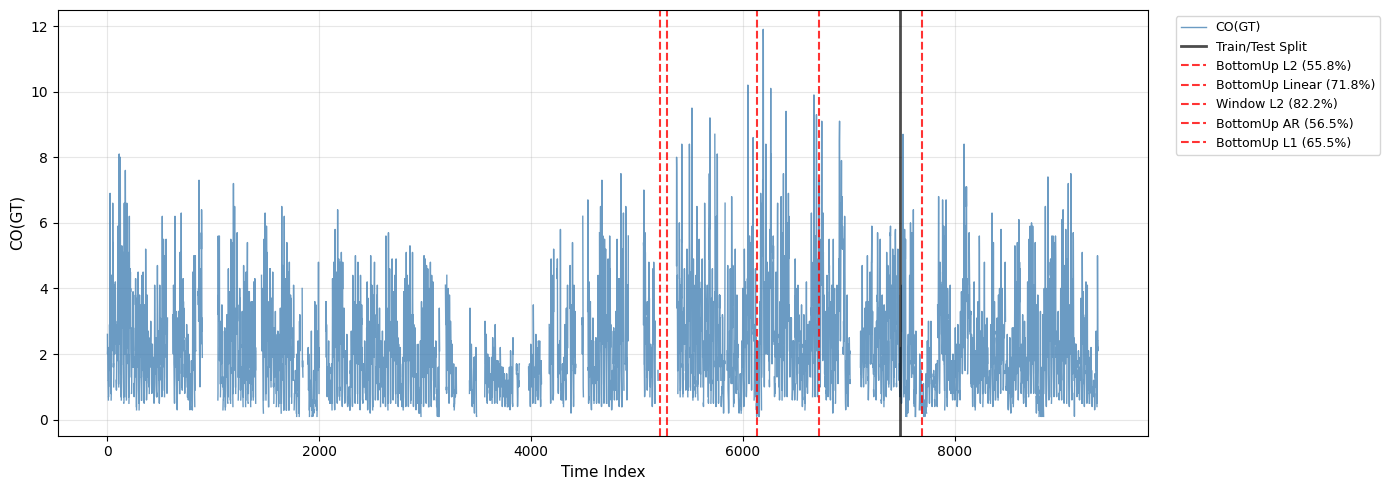


Appliances Energy:


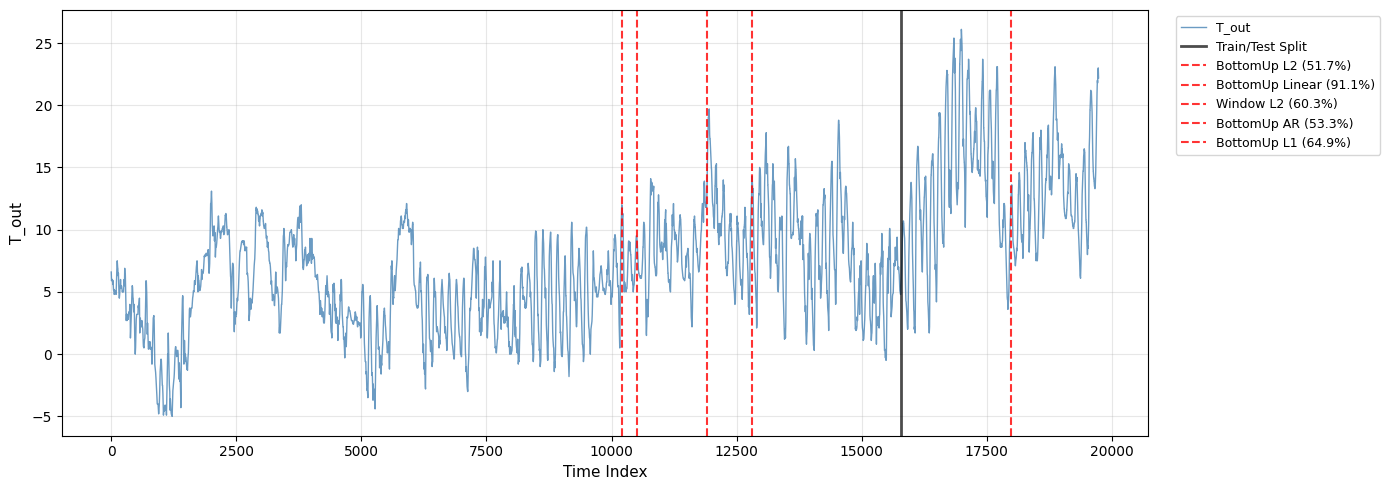


Beijing PM2.5:


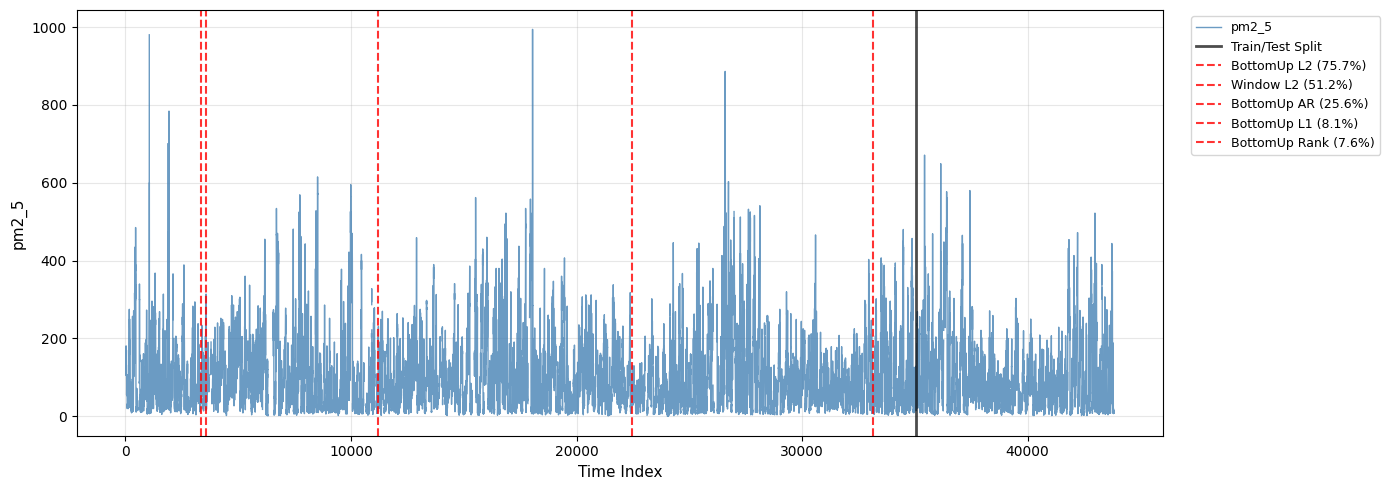


INMET São Paulo:


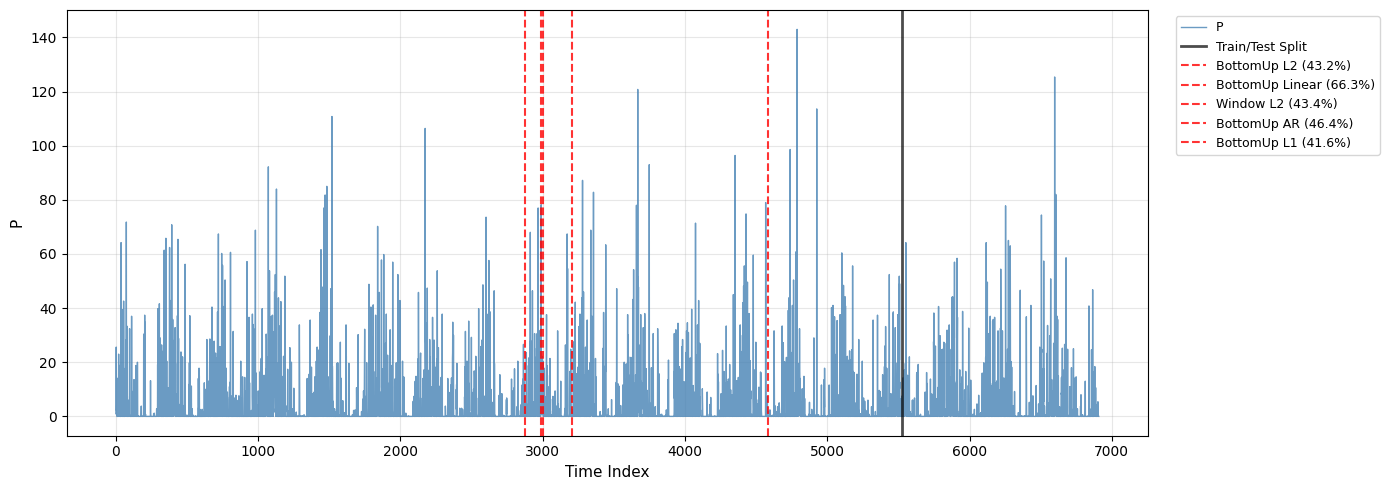


Metro Traffic:


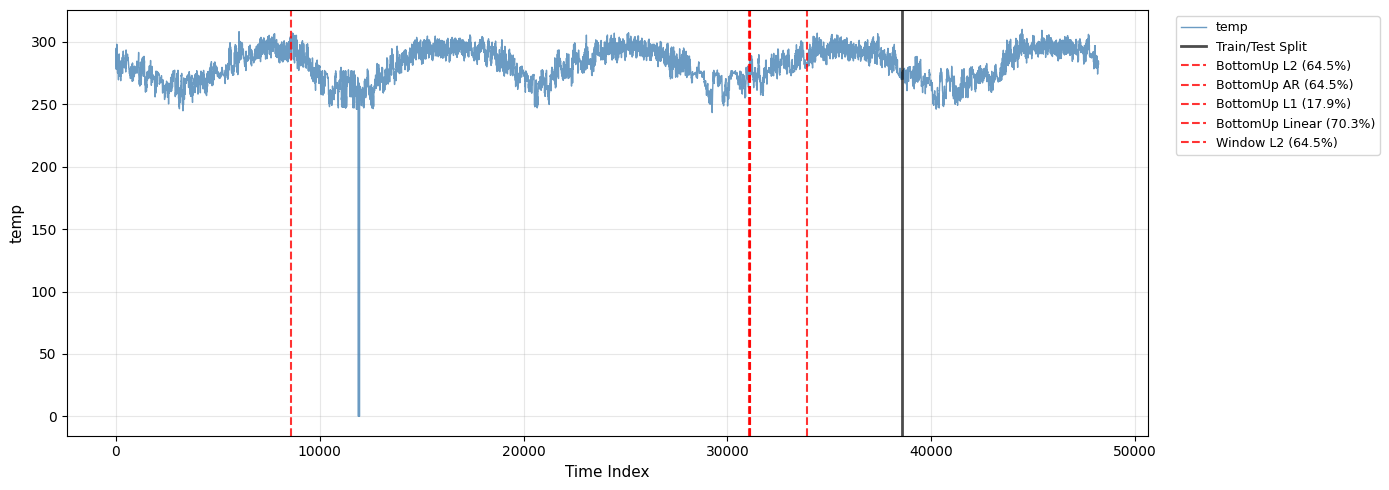


Weather:


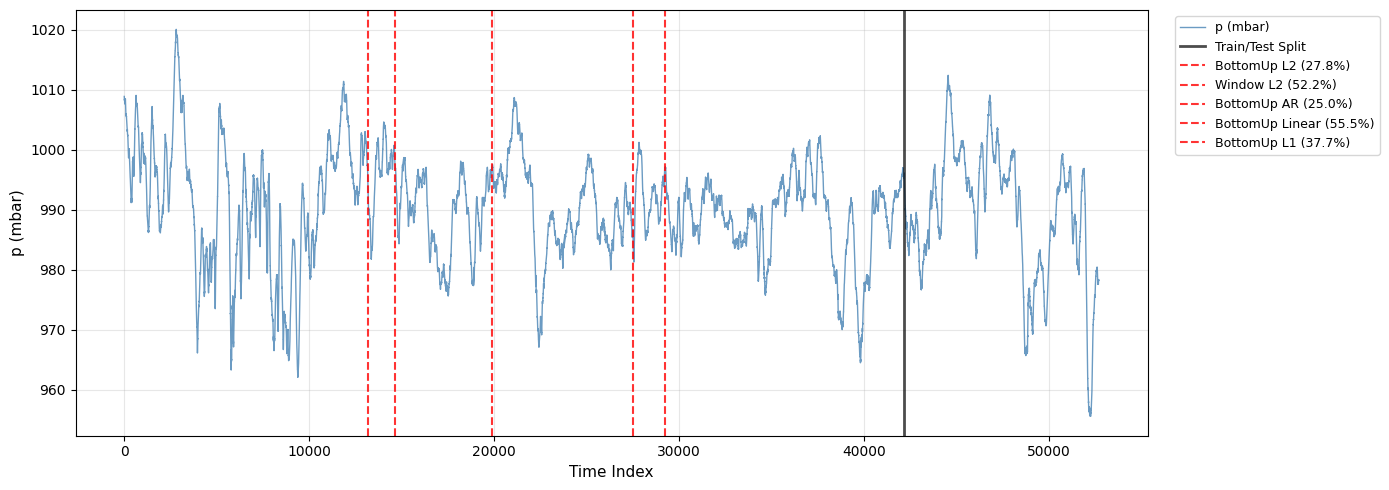

In [4]:
# Plot change points for each dataset (using LSTM metrics as reference)
print("="*60 + "\nCHANGE POINT DETECTION PLOTS\n" + "="*60)
for dataset_name in DATASETS_NAMES:
    print(f"\n{DATASETS_DISPLAY_NAMES[dataset_name]}:")
    plot_change_points(
        dataset_name,
        all_metrics["LSTM"][dataset_name],
        OUTPUT_FOLDER,
        n_approaches=5,
        filename=f"{dataset_name.lower()}_change_points.png"
    )

## 3. Results Tables (Per Forecaster)

In [5]:
print("="*60 + "\nLSTM RESULTS\n" + "="*60)

get_latex_tables(
    all_metrics["LSTM"], col_prefix=RMSE_COL, file_name="rmse_results",
    table_caption="RMSE results (mean $\\pm$ std)", table_label="tab:lstmRmse",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)
get_latex_tables(
    all_metrics["LSTM"], col_prefix=ET_TOTAL_COL, file_name="et_results",
    table_caption="Execution Time in minutes (mean $\\pm$ std)", table_label="tab:lstmEt",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)

LSTM RESULTS
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/LSTM/rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/LSTM/et_results.tex


In [6]:
print("="*60 + "\nTCN RESULTS\n" + "="*60)

get_latex_tables(
    all_metrics["TCN"], col_prefix=RMSE_COL, file_name="rmse_results",
    table_caption="RMSE results (mean $\\pm$ std)", table_label="tab:tcnRmse",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)
get_latex_tables(
    all_metrics["TCN"], col_prefix=ET_TOTAL_COL, file_name="et_results",
    table_caption="Execution Time in minutes (mean $\\pm$ std)", table_label="tab:tcnEt",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)

TCN RESULTS
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/TCN/rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/TCN/et_results.tex


In [7]:
# CPD cuts (same for both forecasters)
get_cpd_cuts_latex_table(all_metrics["LSTM"], OUTPUT_FOLDER, "cpd_cuts")

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/cpd_cuts.tex


In [8]:
# LSTM Fixed Cut tables
get_fixed_cut_latex_tables(
    all_metrics["LSTM"], col_prefix=RMSE_COL, file_name="fixed_cut_rmse_results",
    table_caption="Fixed Cut Baseline RMSE results (mean $\\pm$ std)", table_label="tab:fixedCutRmse",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)
get_fixed_cut_latex_tables(
    all_metrics["LSTM"], col_prefix=ET_TOTAL_COL, file_name="fixed_cut_et_results",
    table_caption="Fixed Cut Baseline Execution Time in minutes (mean $\\pm$ std)", table_label="tab:fixedCutEt",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)

# TCN Fixed Cut tables
get_fixed_cut_latex_tables(
    all_metrics["TCN"], col_prefix=RMSE_COL, file_name="fixed_cut_rmse_results",
    table_caption="Fixed Cut Baseline RMSE results (mean $\\pm$ std)", table_label="tab:fixedCutRmse",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)
get_fixed_cut_latex_tables(
    all_metrics["TCN"], col_prefix=ET_TOTAL_COL, file_name="fixed_cut_et_results",
    table_caption="Fixed Cut Baseline Execution Time in minutes (mean $\\pm$ std)", table_label="tab:fixedCutEt",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/LSTM/fixed_cut_rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/LSTM/fixed_cut_et_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/TCN/fixed_cut_rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/TCN/fixed_cut_et_results.tex


## 4. Statistical Tests (Per Forecaster)

In [9]:
for forecaster in FORECASTER_TYPES:
    print(f"\n{'='*60}\n{forecaster} Friedman Tests\n{'='*60}")
    for name, col in [("RMSE", f"{RMSE_COL}_mean"), ("ET", f"{ET_TOTAL_COL}_mean")]:
        print(f"\n{name}:")
        get_friedman_significance_overall(all_metrics[forecaster], col)


LSTM Friedman Tests

RMSE:
  Friedman Test: stat=36.2805, p=0.199037 (using 31 approaches)
  No significant difference.

ET:
  Friedman Test: stat=93.3427, p=0.000000 (using 31 approaches)
  Significant difference detected.

TCN Friedman Tests

RMSE:
  Friedman Test: stat=62.1359, p=0.000504 (using 31 approaches)
  Significant difference detected.

ET:
  Friedman Test: stat=92.3306, p=0.000000 (using 31 approaches)
  Significant difference detected.


## 5. Multi-Criteria Evaluation (Combined LSTM + TCN)

Ranking approaches across **both forecasters** considering RMSE and Execution Time trade-offs.

In [10]:
# Combine data from both forecasters
combined_dfs = []
for forecaster in FORECASTER_TYPES:
    df = all_comp_dfs[forecaster].copy()
    df['forecaster'] = forecaster
    combined_dfs.append(df)

combined_df = pd.concat(combined_dfs, ignore_index=True)
# Create unique dataset names for analysis (dataset_forecaster)
combined_df[DATASET_NAME_COL] = combined_df[DATASET_NAME_COL] + "_" + combined_df['forecaster']

print(f"Combined: {len(combined_df)} rows = {len(FORECASTER_TYPES)} forecasters x {len(DATASETS_NAMES)} datasets x methods")

Combined: 372 rows = 2 forecasters x 6 datasets x methods


### 5.1 Pareto Frontier Analysis

Running Pareto Analysis with: RMSE (minimize) + ET (minimize)

PARETO FRONT CONSISTENCY ANALYSIS
Optimizing: RMSE + Execution Time

Total datasets analyzed: 12
Total unique methods in any Pareto front: 27

Methods appearing in ALL Pareto fronts (12/12 = 100%):
  None

Methods appearing in majority of Pareto fronts (>= 50%):
  - Fixed Cut 90%: 9/12 (75.0%)
  - Fixed Cut 70%: 6/12 (50.0%)
  - Fixed Cut 80%: 6/12 (50.0%)
  - Window RBF: 6/12 (50.0%)


,Method,Pareto Count,Pareto Percentage,Datasets
6,Fixed Cut 90%,9,75.0,"UCI_AIR_QUALITY_LSTM, UCI_PRSA_BEIJING_LSTM, I..."
19,Window RBF,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, UCI_PRSA_BEIJING_L..."
17,Fixed Cut 80%,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, INMET_SAOPAULO_SP_..."
16,Fixed Cut 70%,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, UCI_PRSA_BEIJING_L..."
20,Window L1,5,41.7,"UCI_PRSA_BEIJING_LSTM, INMET_SAOPAULO_SP_LSTM,..."
7,Window Normal,5,41.7,"UCI_AIR_QUALITY_LSTM, INMET_SAOPAULO_SP_LSTM, ..."
15,Fixed Cut 40%,4,33.3,"UCI_APPLIANCES_ENERGY_LSTM, UCI_AIR_QUALITY_TC..."
21,Window Linear,4,33.3,"UCI_PRSA_BEIJING_LSTM, INMET_SAOPAULO_SP_LSTM,..."
5,Fixed Cut 60%,4,33.3,"UCI_AIR_QUALITY_LSTM, INMET_SAOPAULO_SP_LSTM, ..."
18,Window L2,4,33.3,"UCI_APPLIANCES_ENERGY_LSTM, UCI_METRO_TRAFFIC_..."


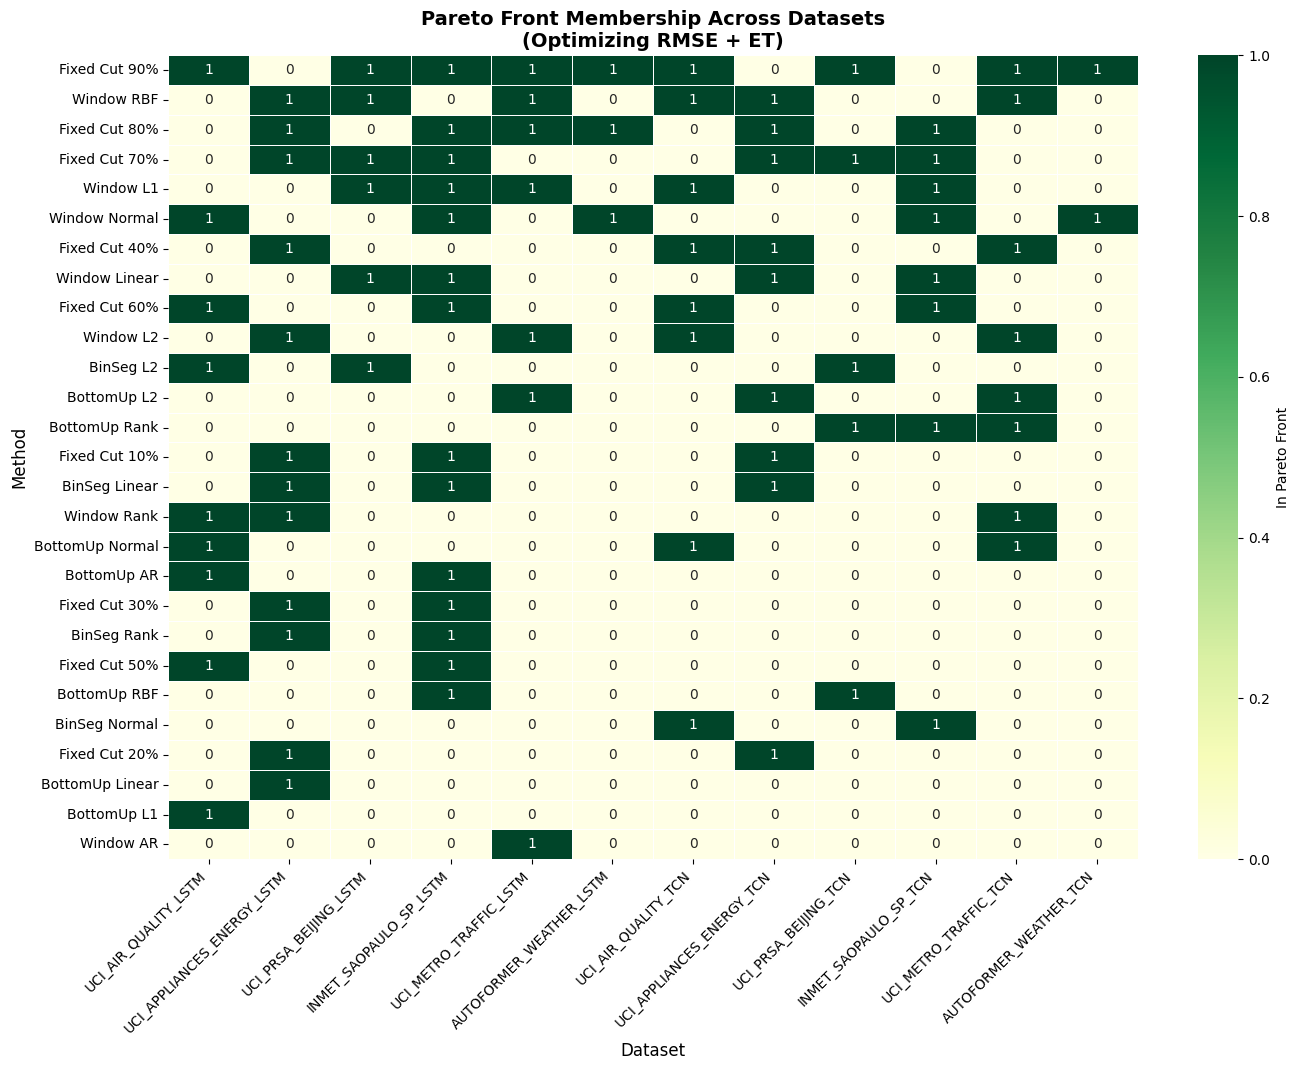

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/pareto_combined.xlsx


In [11]:
pareto_summary, pareto_by_ds = analyze_pareto_consistency(combined_df, PRIMARY_METRIC, OUTPUT_FOLDER)
display_with_latex(pareto_summary, "Pareto Front Consistency (LSTM+TCN)", "tab:paretoCombined")
plot_pareto_heatmap(pareto_summary, pareto_by_ds, PRIMARY_METRIC, OUTPUT_FOLDER)
save_results_to_excel(pareto_summary, OUTPUT_FOLDER, "pareto_combined")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


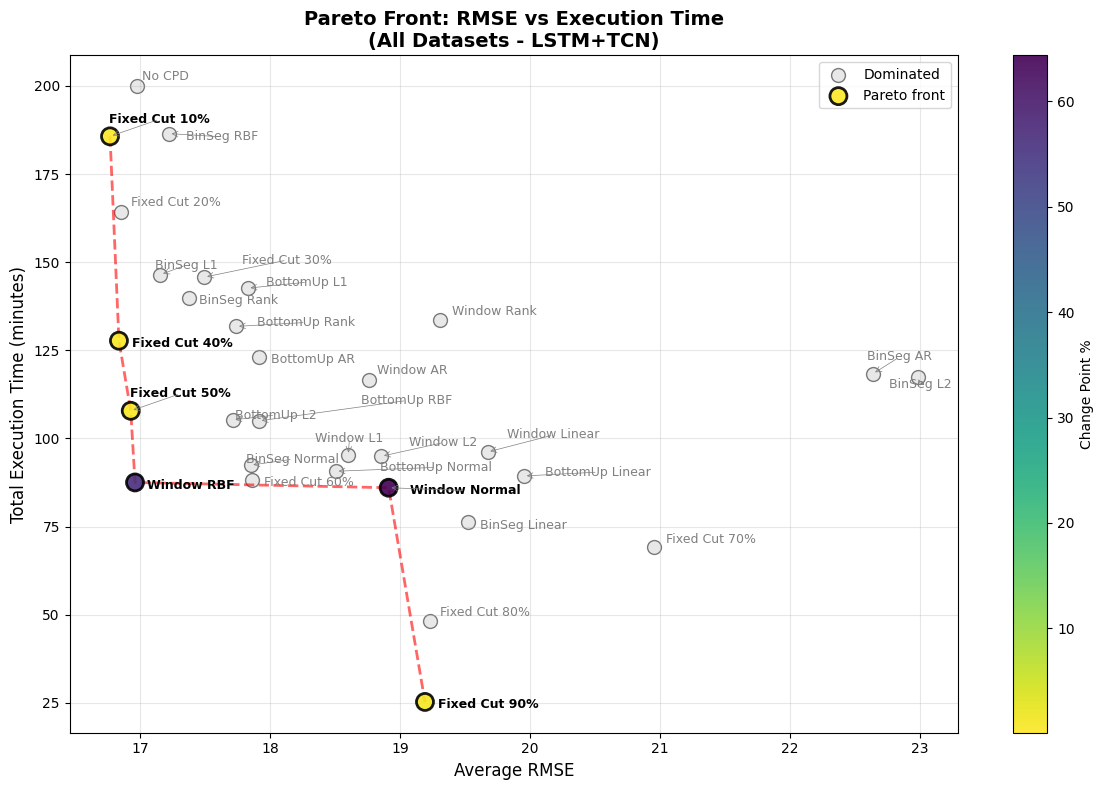


Pareto Optimal Approaches - All Datasets / LSTM+TCN (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 16.7710 | ET:   185.70 min
Fixed Cut 40%                  | RMSE: 16.8396 | ET:   127.73 min
Fixed Cut 50%                  | RMSE: 16.9303 | ET:   107.86 min
Window RBF                     | RMSE: 16.9632 | ET:    87.53 min
Window Normal                  | RMSE: 18.9135 | ET:    86.03 min
Fixed Cut 90%                  | RMSE: 19.1930 | ET:    25.28 min


,change_point_approach,Avg_RMSE,ET_Total,change_point_perc,is_pareto
14,Fixed Cut 10%,16.771025,185.702358,0.100000,True
17,Fixed Cut 40%,16.839600,127.734700,0.400000,True
18,Fixed Cut 50%,16.930317,107.855767,0.500000,True
29,Window RBF,16.963183,87.533400,56.137783,True
28,Window Normal,18.913517,86.034875,64.364567,True
22,Fixed Cut 90%,19.192967,25.280192,0.900000,True


In [12]:
# Aggregate combined data to get mean values across all datasets/forecasters
combined_agg = combined_df.groupby(CHANGE_POINT_APPROACH_COL).agg({
    f"{PRIMARY_METRIC}_mean": "mean",
    f"{ET_TOTAL_COL}_mean": "mean",
    f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": "mean"
}).reset_index()

# Rename columns to match plot_pareto_front expectations
combined_agg = combined_agg.rename(columns={
    f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
    f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
    f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL
})

# Plot the combined Pareto front
plot_pareto_front(
    combined_agg, 
    OUTPUT_FOLDER, 
    PRIMARY_METRIC,
    filename="pareto_front_combined.png",
    dataset_name="All Datasets",
    forecaster_type="LSTM+TCN"
)

### 5.2 Weighted Scalarization

In [13]:
ws_df = compute_weighted_scalarization_sensitivity(combined_df, PRIMARY_METRIC)
display_with_latex(ws_df, "Weighted Scalarization (LSTM+TCN)", "tab:weightedCombined", precision=0)
save_results_to_excel(ws_df, OUTPUT_FOLDER, "weighted_scalarization_combined")

,change_point_approach,α=0.1,α=0.3,α=0.5,α=0.7,α=0.9,avg_rank
29,Window RBF,5.0,3.0,1.0,1.0,1.0,2.2
18,Fixed Cut 50%,15.0,7.0,3.0,2.0,3.0,6.0
19,Fixed Cut 60%,6.0,4.0,5.0,4.0,12.0,6.2
4,BinSeg Normal,8.0,5.0,6.0,5.0,13.0,7.4
22,Fixed Cut 90%,1.0,1.0,2.0,11.0,23.0,7.6
17,Fixed Cut 40%,19.0,16.0,7.0,3.0,2.0,9.4
9,BottomUp L2,14.0,10.0,8.0,6.0,11.0,9.8
21,Fixed Cut 80%,2.0,2.0,4.0,17.0,24.0,9.8
11,BottomUp Normal,9.0,8.0,10.0,16.0,18.0,12.2
12,BottomUp RBF,16.0,12.0,9.0,10.0,15.0,12.4


Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/weighted_scalarization_combined.xlsx


### 5.3 Dominance Ranking

In [14]:
dom_df = compute_dominance_ranking(combined_df, PRIMARY_METRIC)
display_with_latex(dom_df, "Dominance Ranking (LSTM+TCN)", "tab:dominanceCombined")
save_results_to_excel(dom_df, OUTPUT_FOLDER, "dominance_ranking_combined")

,change_point_approach,Avg_RMSE_mean,ET_Total_mean,dominated_count,rank
14,Fixed Cut 10%,16.771025,185.702358,0,1.0
17,Fixed Cut 40%,16.839600,127.734700,0,1.0
18,Fixed Cut 50%,16.930317,107.855767,0,1.0
29,Window RBF,16.963183,87.533400,0,1.0
28,Window Normal,18.913517,86.034875,0,1.0
22,Fixed Cut 90%,19.192967,25.280192,0,1.0
15,Fixed Cut 20%,16.857642,164.199725,1,7.0
9,BottomUp L2,17.713475,105.253192,1,7.0
4,BinSeg Normal,17.851708,92.436892,1,7.0
19,Fixed Cut 60%,17.862150,88.259192,1,7.0


Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v2/dominance_ranking_combined.xlsx


## 6. Visualizations


LSTM:


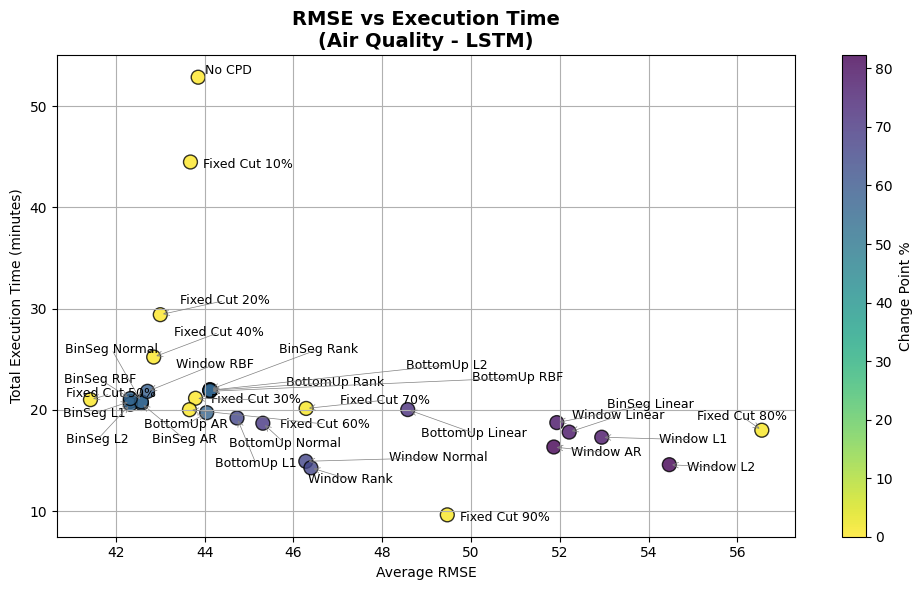

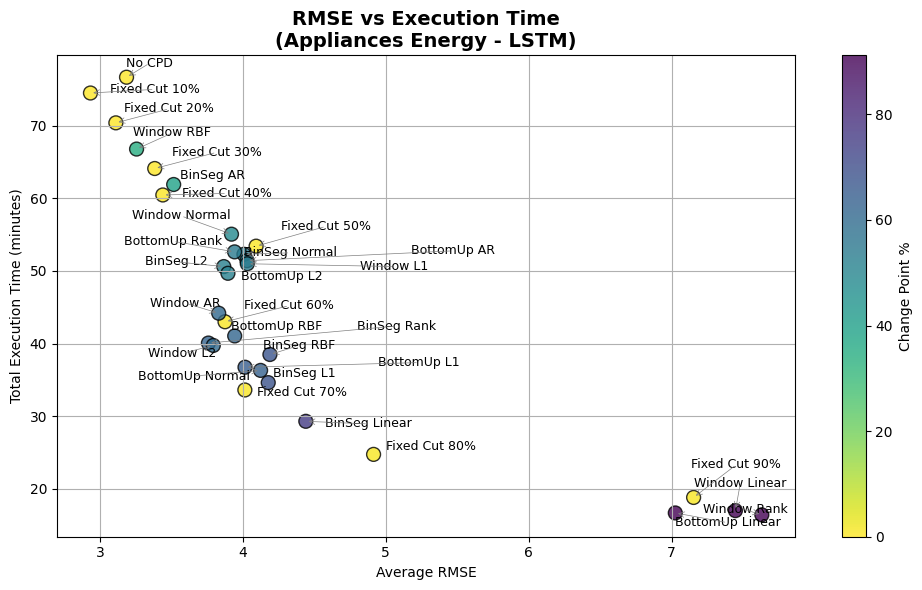

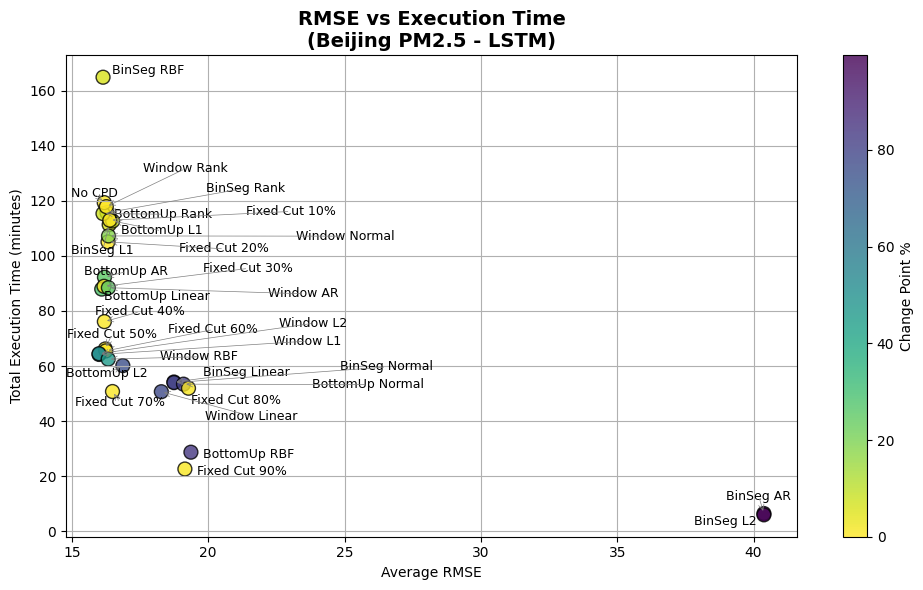

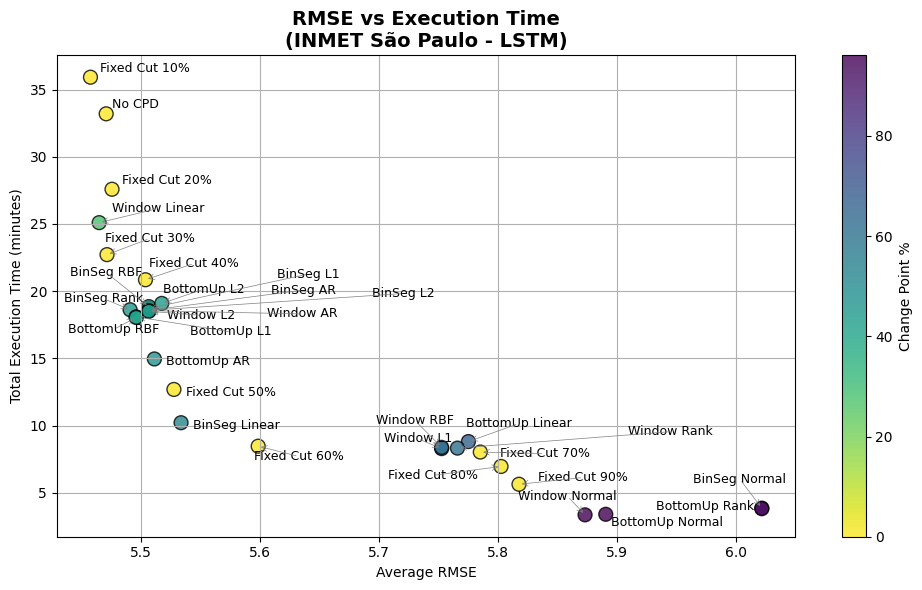

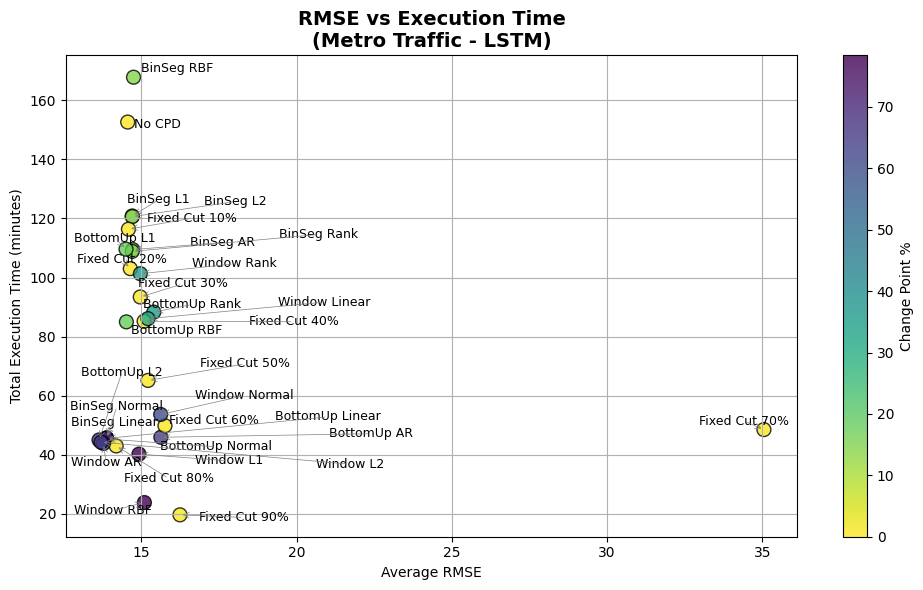

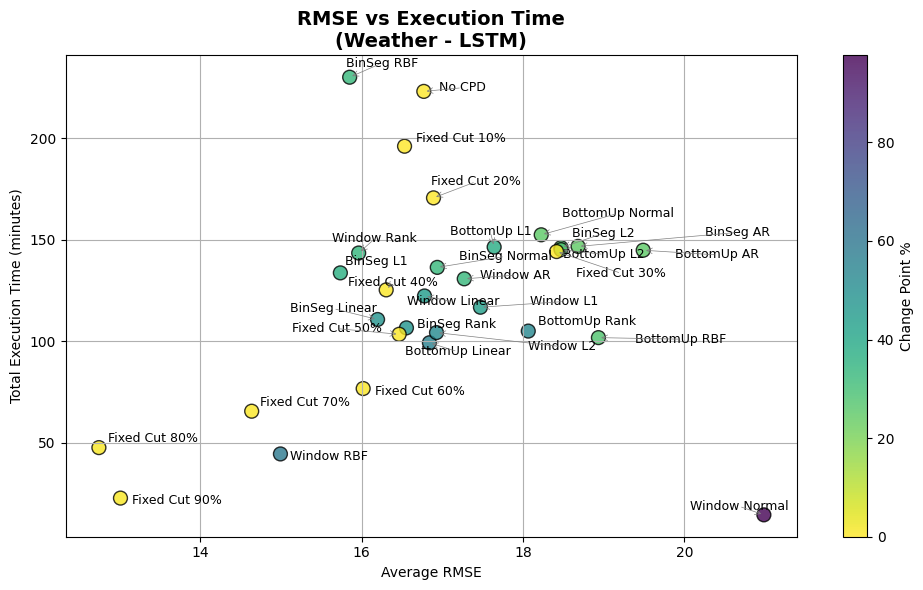


TCN:


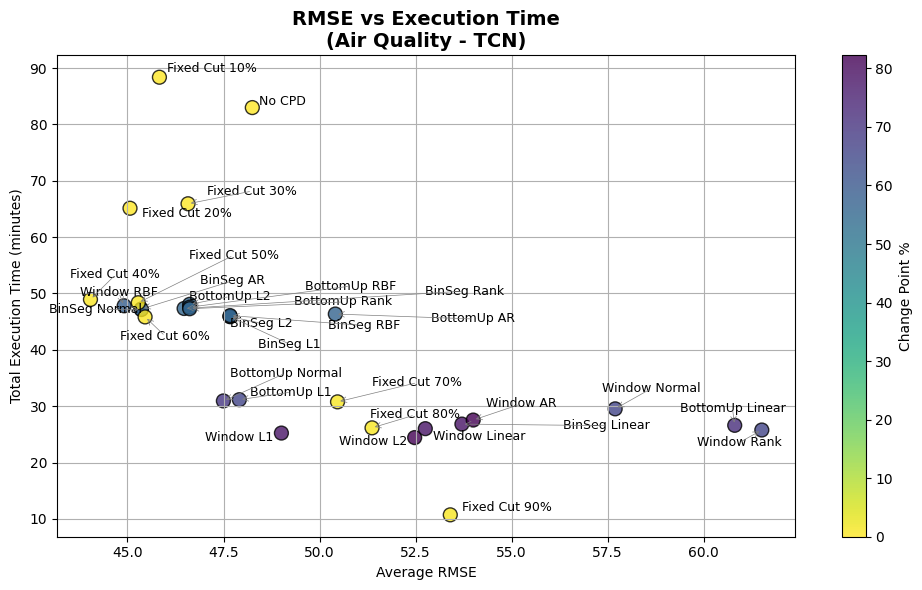

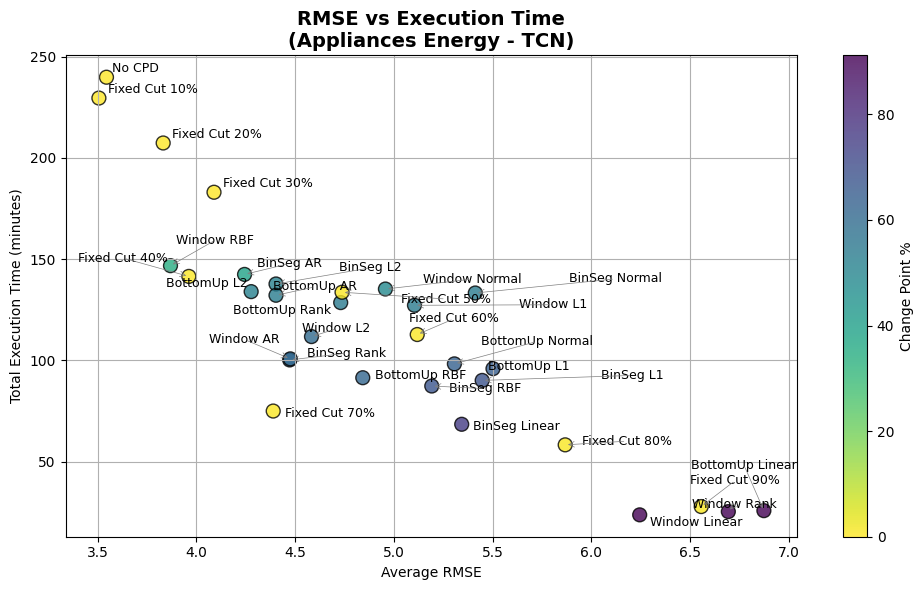

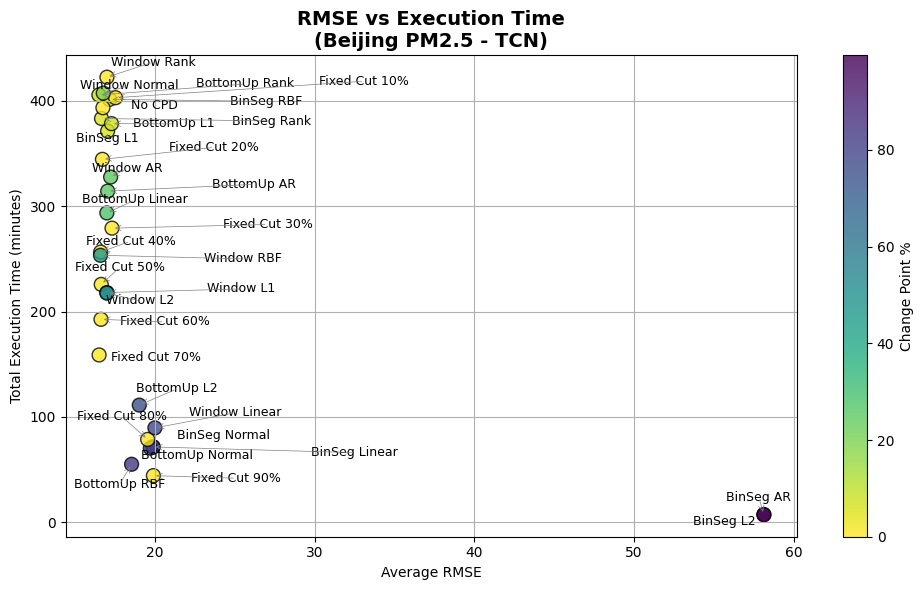

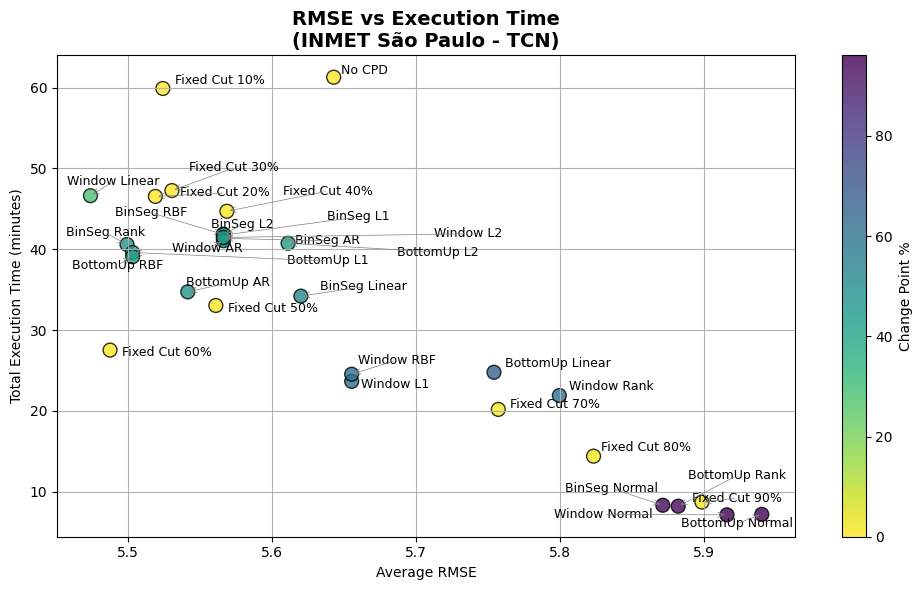

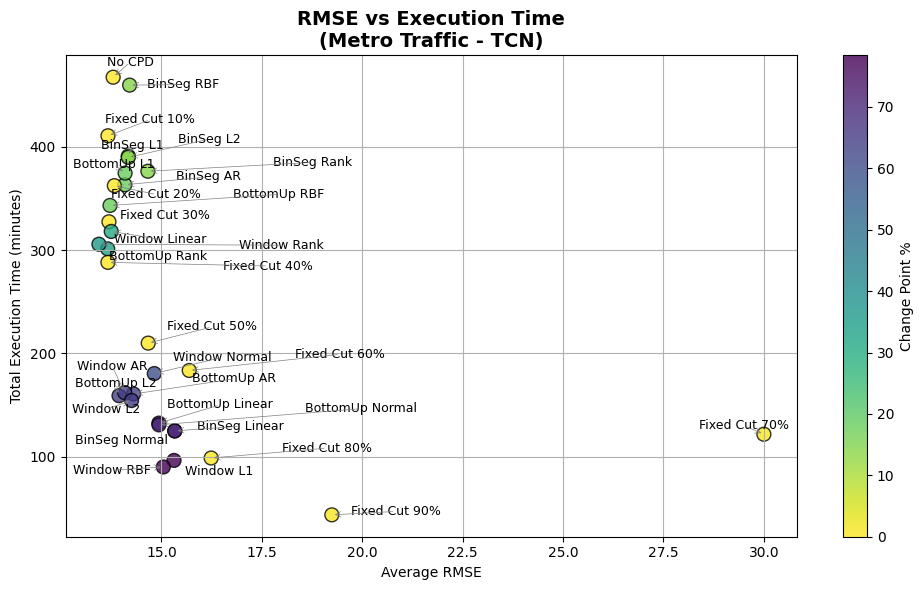

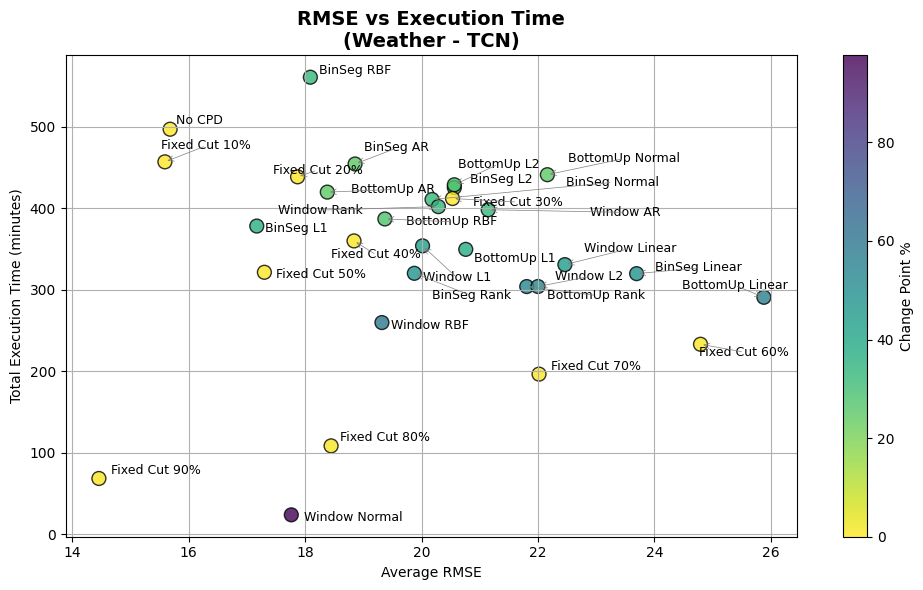

In [15]:
# Scatter plots per forecaster
for forecaster in FORECASTER_TYPES:
    print(f"\n{forecaster}:")
    for ds in DATASETS_NAMES:
        df = all_comp_dfs[forecaster][all_comp_dfs[forecaster][DATASET_NAME_COL] == ds].rename(columns={
            f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL,
            f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
            f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
        })
        plot_scatter_plot(df, f"{OUTPUT_FOLDER}/{forecaster}", PRIMARY_METRIC, 
                          filename=f"{ds}_scatter.png", dataset_name=ds, forecaster_type=forecaster)


LSTM:


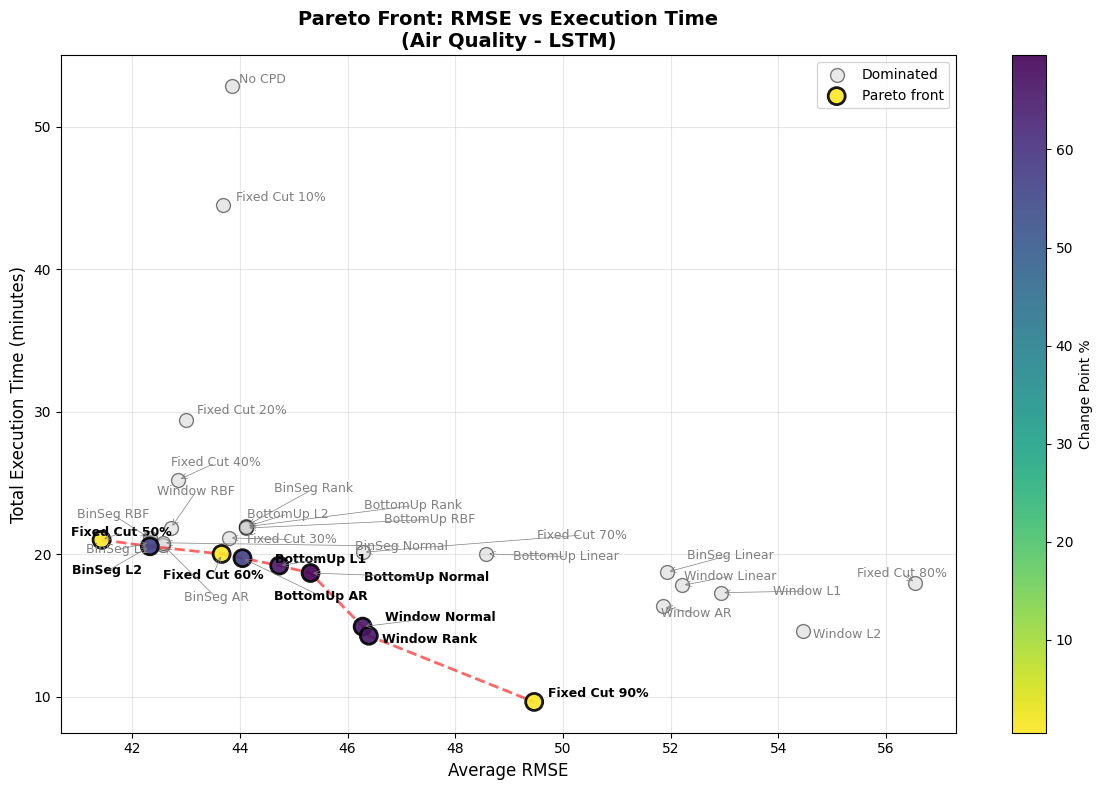


Pareto Optimal Approaches - Air Quality / LSTM (optimizing RMSE and ET):
Fixed Cut 50%                  | RMSE: 41.4297 | ET:    21.02 min
BinSeg L2                      | RMSE: 42.3267 | ET:    20.56 min
Fixed Cut 60%                  | RMSE: 43.6592 | ET:    20.02 min
BottomUp AR                    | RMSE: 44.0474 | ET:    19.73 min
BottomUp L1                    | RMSE: 44.7295 | ET:    19.21 min
BottomUp Normal                | RMSE: 45.3114 | ET:    18.69 min
Window Normal                  | RMSE: 46.2791 | ET:    14.92 min
Window Rank                    | RMSE: 46.3945 | ET:    14.28 min
Fixed Cut 90%                  | RMSE: 49.4660 | ET:     9.64 min


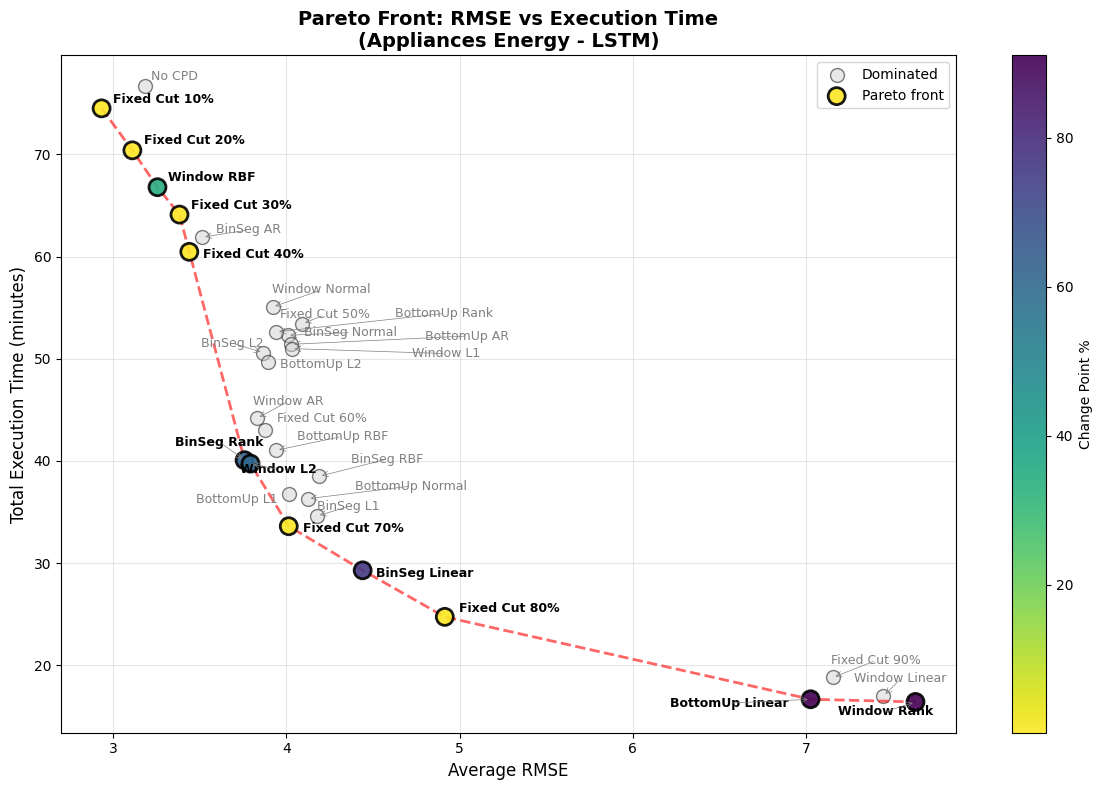


Pareto Optimal Approaches - Appliances Energy / LSTM (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 2.9346 | ET:    74.51 min
Fixed Cut 20%                  | RMSE: 3.1122 | ET:    70.40 min
Window RBF                     | RMSE: 3.2571 | ET:    66.79 min
Fixed Cut 30%                  | RMSE: 3.3841 | ET:    64.11 min
Fixed Cut 40%                  | RMSE: 3.4408 | ET:    60.47 min
BinSeg Rank                    | RMSE: 3.7597 | ET:    40.07 min
Window L2                      | RMSE: 3.7940 | ET:    39.74 min
Fixed Cut 70%                  | RMSE: 4.0147 | ET:    33.60 min
BinSeg Linear                  | RMSE: 4.4411 | ET:    29.29 min
Fixed Cut 80%                  | RMSE: 4.9152 | ET:    24.73 min
BottomUp Linear                | RMSE: 7.0261 | ET:    16.66 min
Window Rank                    | RMSE: 7.6314 | ET:    16.40 min


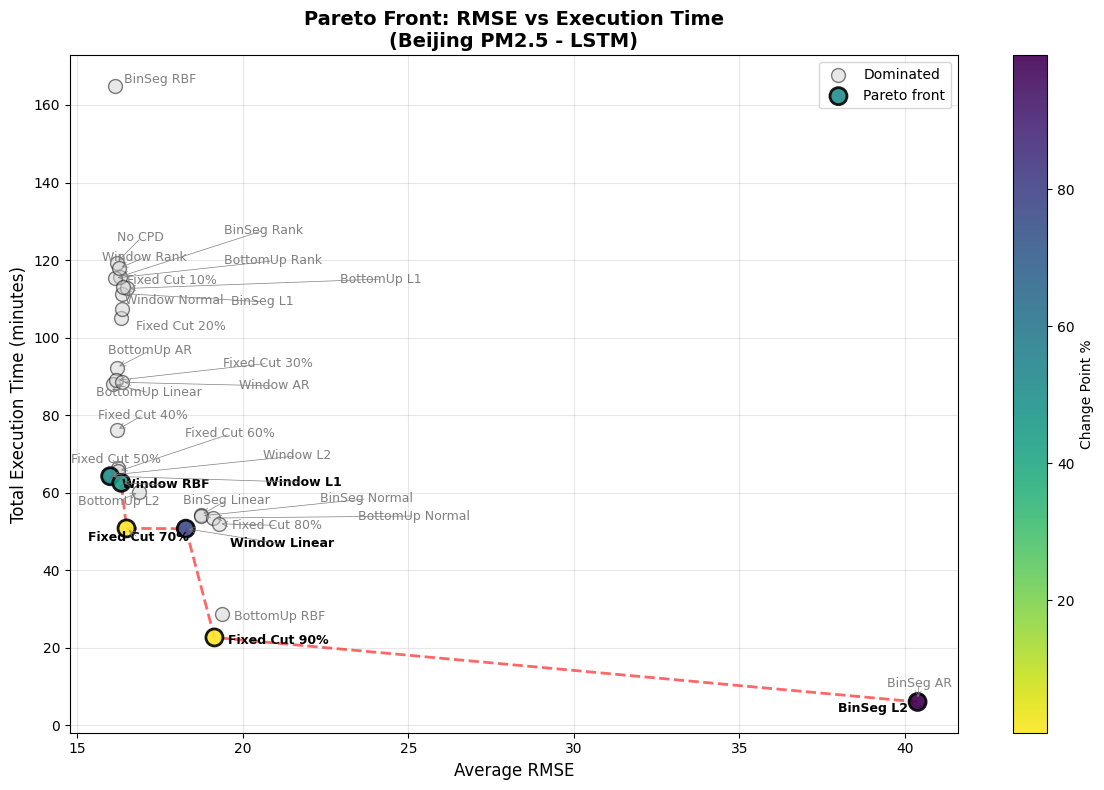


Pareto Optimal Approaches - Beijing PM2.5 / LSTM (optimizing RMSE and ET):
Window L1                      | RMSE: 15.9973 | ET:    64.22 min
Window RBF                     | RMSE: 16.3331 | ET:    62.52 min
Fixed Cut 70%                  | RMSE: 16.4915 | ET:    50.76 min
Window Linear                  | RMSE: 18.2824 | ET:    50.70 min
Fixed Cut 90%                  | RMSE: 19.1462 | ET:    22.63 min
BinSeg L2                      | RMSE: 40.3799 | ET:     5.99 min


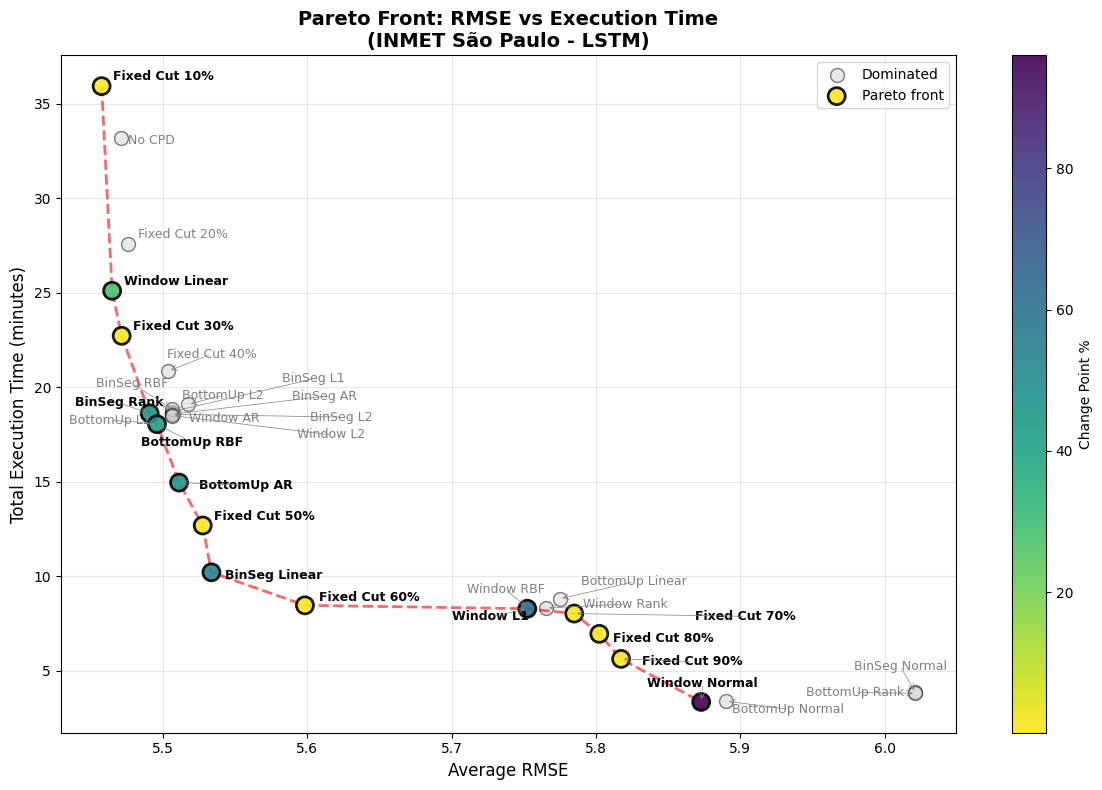


Pareto Optimal Approaches - INMET São Paulo / LSTM (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 5.4574 | ET:    35.92 min
Window Linear                  | RMSE: 5.4647 | ET:    25.10 min
Fixed Cut 30%                  | RMSE: 5.4713 | ET:    22.72 min
BinSeg Rank                    | RMSE: 5.4907 | ET:    18.62 min
BottomUp RBF                   | RMSE: 5.4958 | ET:    18.05 min
BottomUp AR                    | RMSE: 5.5111 | ET:    14.96 min
Fixed Cut 50%                  | RMSE: 5.5275 | ET:    12.69 min
BinSeg Linear                  | RMSE: 5.5335 | ET:    10.22 min
Fixed Cut 60%                  | RMSE: 5.5983 | ET:     8.47 min
Window L1                      | RMSE: 5.7524 | ET:     8.29 min
Fixed Cut 70%                  | RMSE: 5.7849 | ET:     8.03 min
Fixed Cut 80%                  | RMSE: 5.8023 | ET:     6.96 min
Fixed Cut 90%                  | RMSE: 5.8174 | ET:     5.64 min
Window Normal                  | RMSE: 5.8729 | ET:     3.36 min


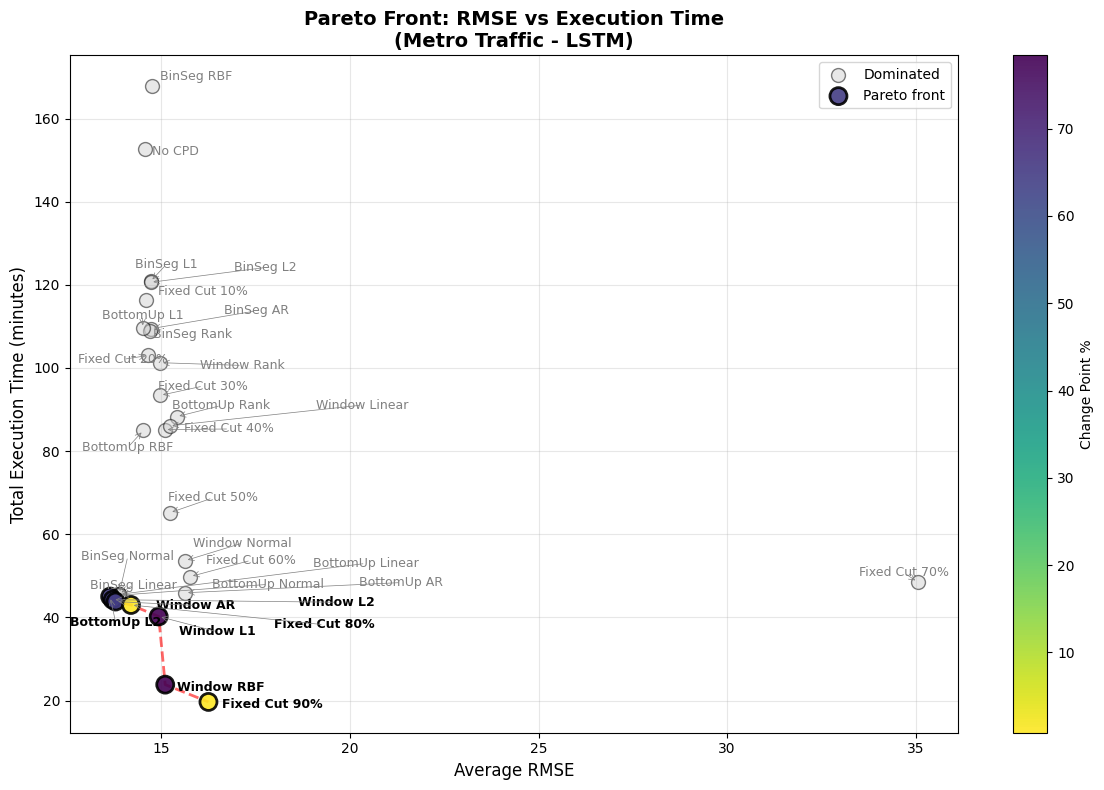


Pareto Optimal Approaches - Metro Traffic / LSTM (optimizing RMSE and ET):
BottomUp L2                    | RMSE: 13.6410 | ET:    45.02 min
Window L2                      | RMSE: 13.7069 | ET:    44.26 min
Window AR                      | RMSE: 13.7831 | ET:    43.82 min
Fixed Cut 80%                  | RMSE: 14.1937 | ET:    43.00 min
Window L1                      | RMSE: 14.9277 | ET:    40.23 min
Window RBF                     | RMSE: 15.1015 | ET:    23.83 min
Fixed Cut 90%                  | RMSE: 16.2478 | ET:    19.67 min


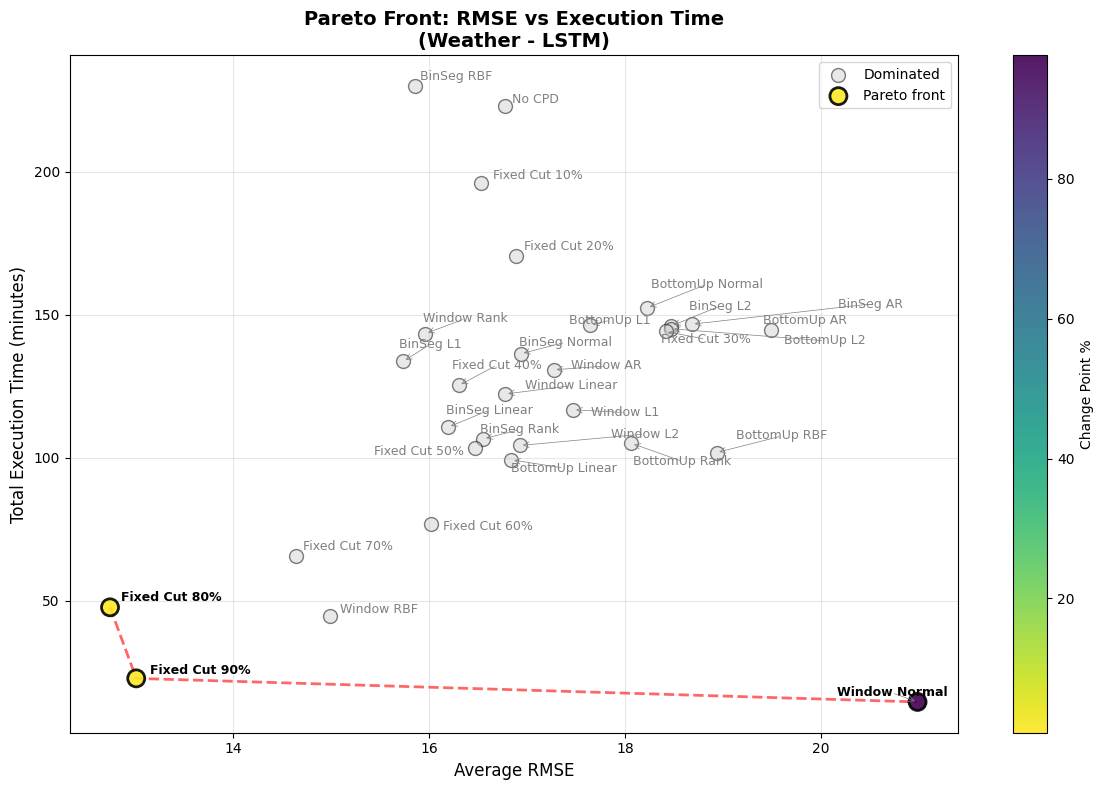


Pareto Optimal Approaches - Weather / LSTM (optimizing RMSE and ET):
Fixed Cut 80%                  | RMSE: 12.7434 | ET:    47.69 min
Fixed Cut 90%                  | RMSE: 13.0109 | ET:    22.84 min
Window Normal                  | RMSE: 20.9859 | ET:    14.60 min

TCN:


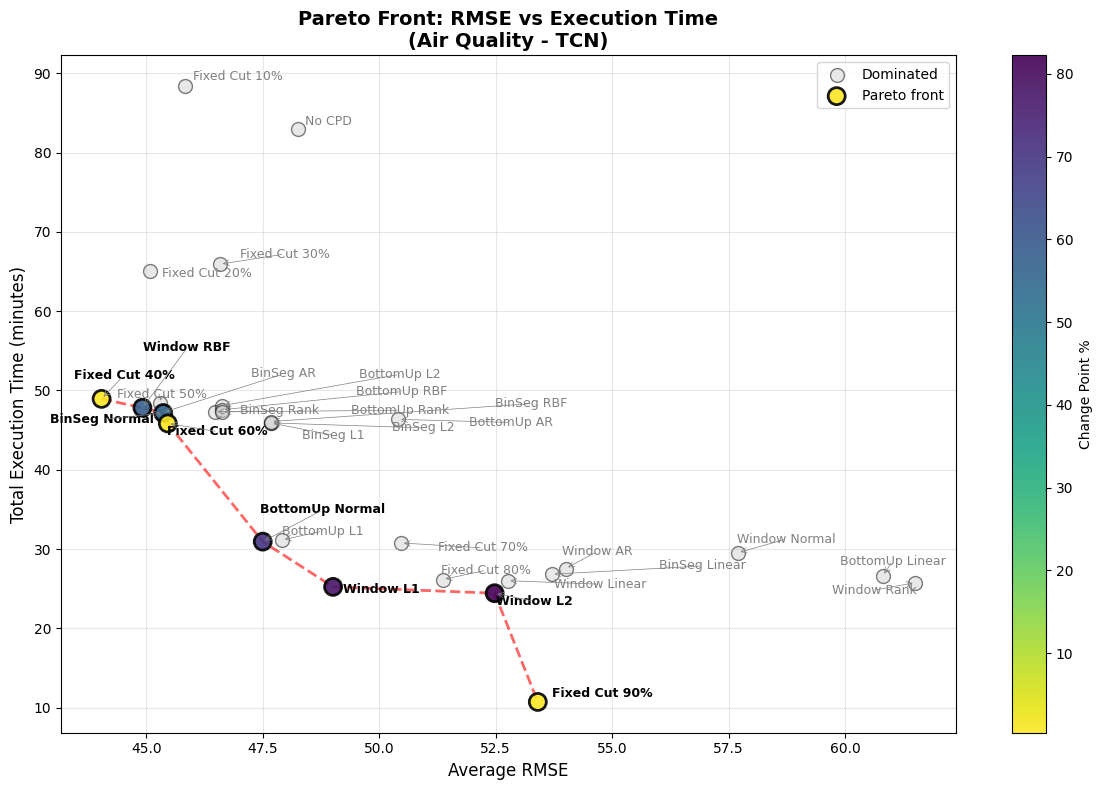


Pareto Optimal Approaches - Air Quality / TCN (optimizing RMSE and ET):
Fixed Cut 40%                  | RMSE: 44.0362 | ET:    48.94 min
Window RBF                     | RMSE: 44.9130 | ET:    47.81 min
BinSeg Normal                  | RMSE: 45.3601 | ET:    47.15 min
Fixed Cut 60%                  | RMSE: 45.4581 | ET:    45.84 min
BottomUp Normal                | RMSE: 47.4962 | ET:    30.93 min
Window L1                      | RMSE: 49.0070 | ET:    25.23 min
Window L2                      | RMSE: 52.4763 | ET:    24.43 min
Fixed Cut 90%                  | RMSE: 53.4033 | ET:    10.72 min


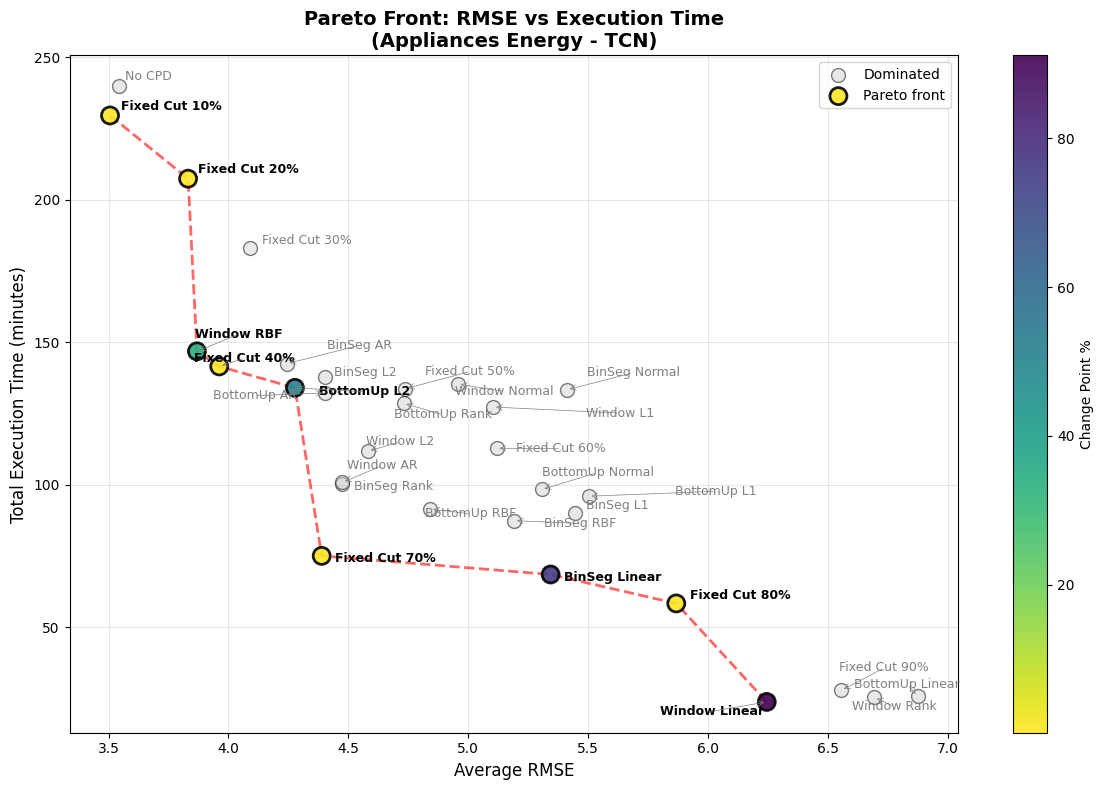


Pareto Optimal Approaches - Appliances Energy / TCN (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 3.5058 | ET:   229.54 min
Fixed Cut 20%                  | RMSE: 3.8314 | ET:   207.36 min
Window RBF                     | RMSE: 3.8685 | ET:   146.79 min
Fixed Cut 40%                  | RMSE: 3.9615 | ET:   141.49 min
BottomUp L2                    | RMSE: 4.2771 | ET:   133.98 min
Fixed Cut 70%                  | RMSE: 4.3888 | ET:    75.02 min
BinSeg Linear                  | RMSE: 5.3437 | ET:    68.49 min
Fixed Cut 80%                  | RMSE: 5.8679 | ET:    58.33 min
Window Linear                  | RMSE: 6.2453 | ET:    23.78 min


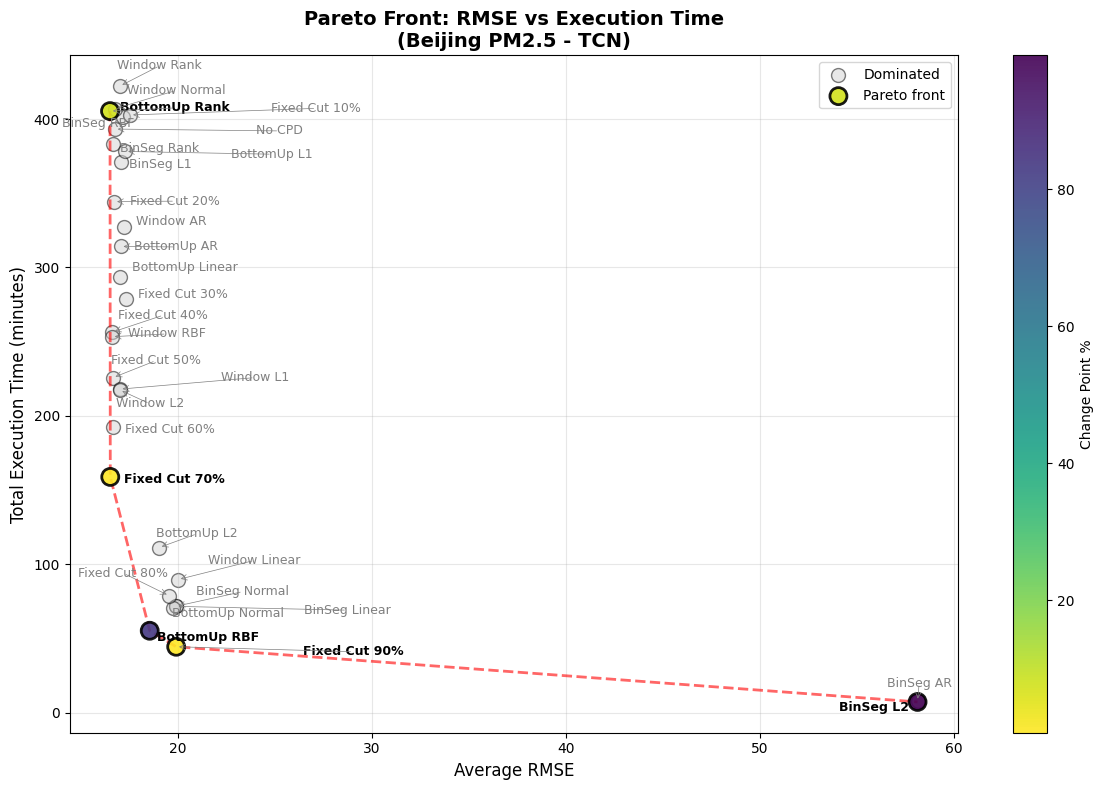


Pareto Optimal Approaches - Beijing PM2.5 / TCN (optimizing RMSE and ET):
BottomUp Rank                  | RMSE: 16.5023 | ET:   405.37 min
Fixed Cut 70%                  | RMSE: 16.5151 | ET:   158.84 min
BottomUp RBF                   | RMSE: 18.5485 | ET:    55.18 min
Fixed Cut 90%                  | RMSE: 19.9126 | ET:    44.40 min
BinSeg L2                      | RMSE: 58.1282 | ET:     7.22 min


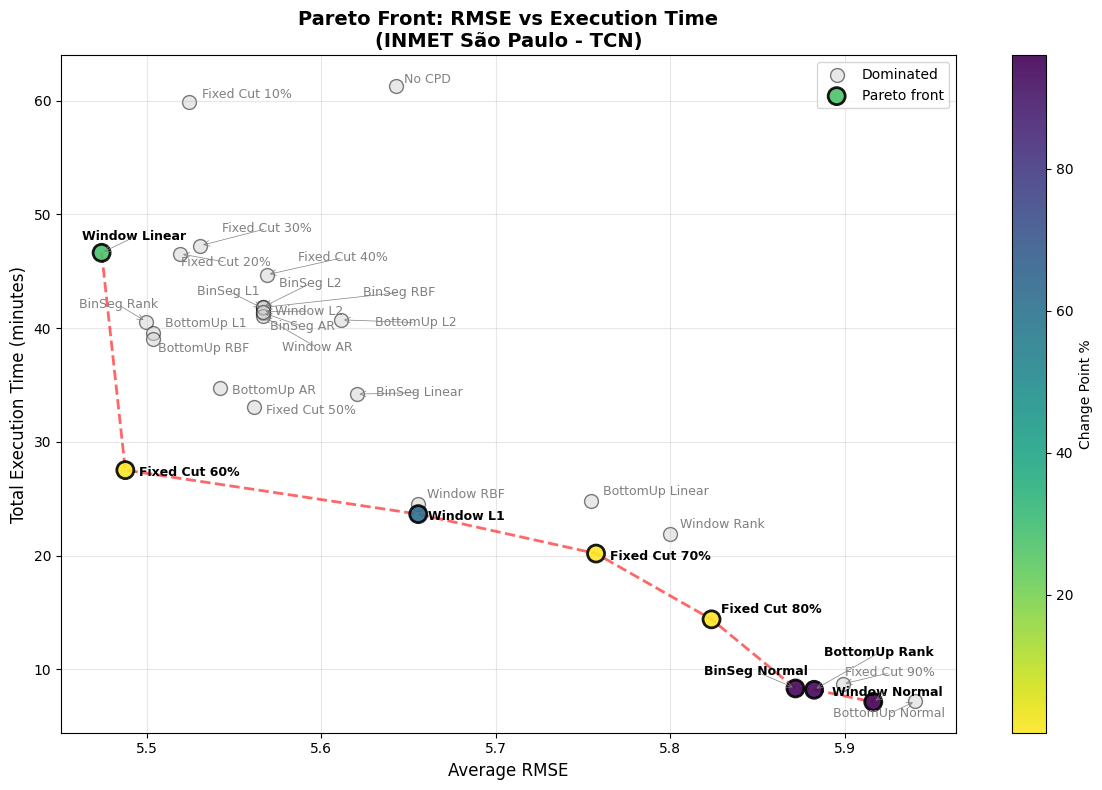


Pareto Optimal Approaches - INMET São Paulo / TCN (optimizing RMSE and ET):
Window Linear                  | RMSE: 5.4740 | ET:    46.63 min
Fixed Cut 60%                  | RMSE: 5.4876 | ET:    27.52 min
Window L1                      | RMSE: 5.6555 | ET:    23.65 min
Fixed Cut 70%                  | RMSE: 5.7574 | ET:    20.18 min
Fixed Cut 80%                  | RMSE: 5.8236 | ET:    14.39 min
BinSeg Normal                  | RMSE: 5.8717 | ET:     8.32 min
BottomUp Rank                  | RMSE: 5.8824 | ET:     8.20 min
Window Normal                  | RMSE: 5.9163 | ET:     7.13 min


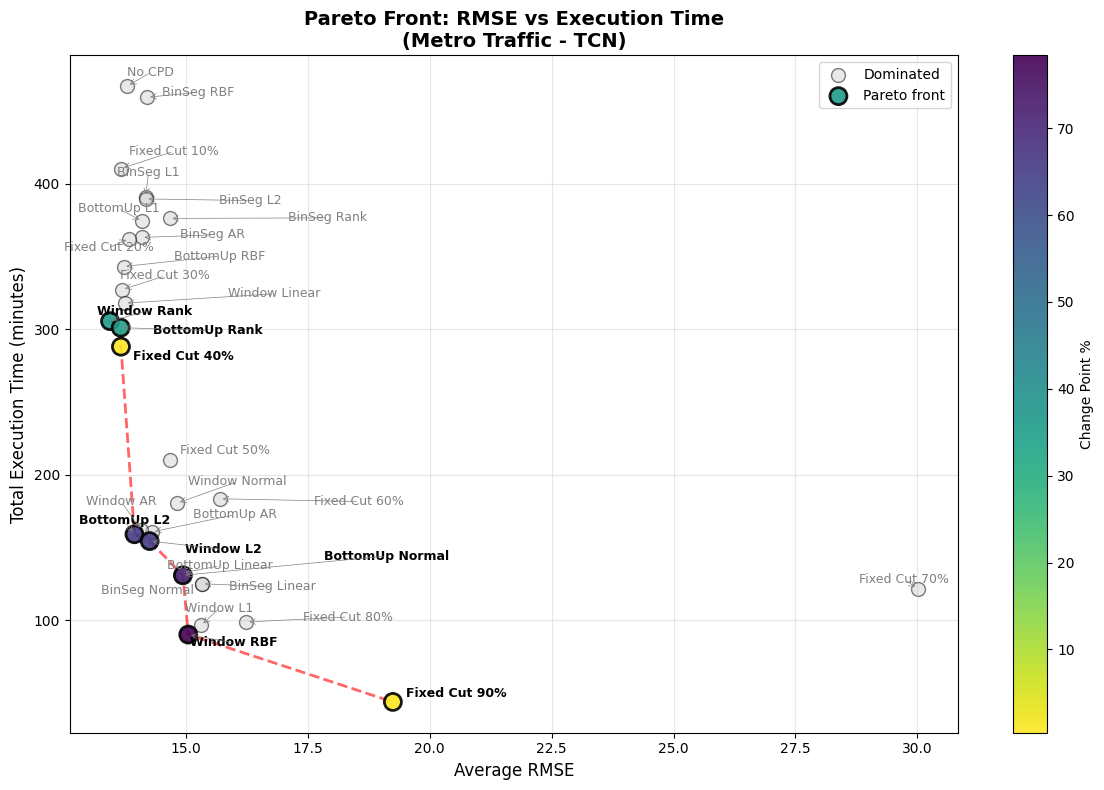


Pareto Optimal Approaches - Metro Traffic / TCN (optimizing RMSE and ET):
Window Rank                    | RMSE: 13.4444 | ET:   305.67 min
BottomUp Rank                  | RMSE: 13.6637 | ET:   301.18 min
Fixed Cut 40%                  | RMSE: 13.6686 | ET:   288.12 min
BottomUp L2                    | RMSE: 13.9453 | ET:   159.12 min
Window L2                      | RMSE: 14.2574 | ET:   154.43 min
BottomUp Normal                | RMSE: 14.9377 | ET:   130.90 min
Window RBF                     | RMSE: 15.0488 | ET:    90.13 min
Fixed Cut 90%                  | RMSE: 19.2446 | ET:    43.82 min


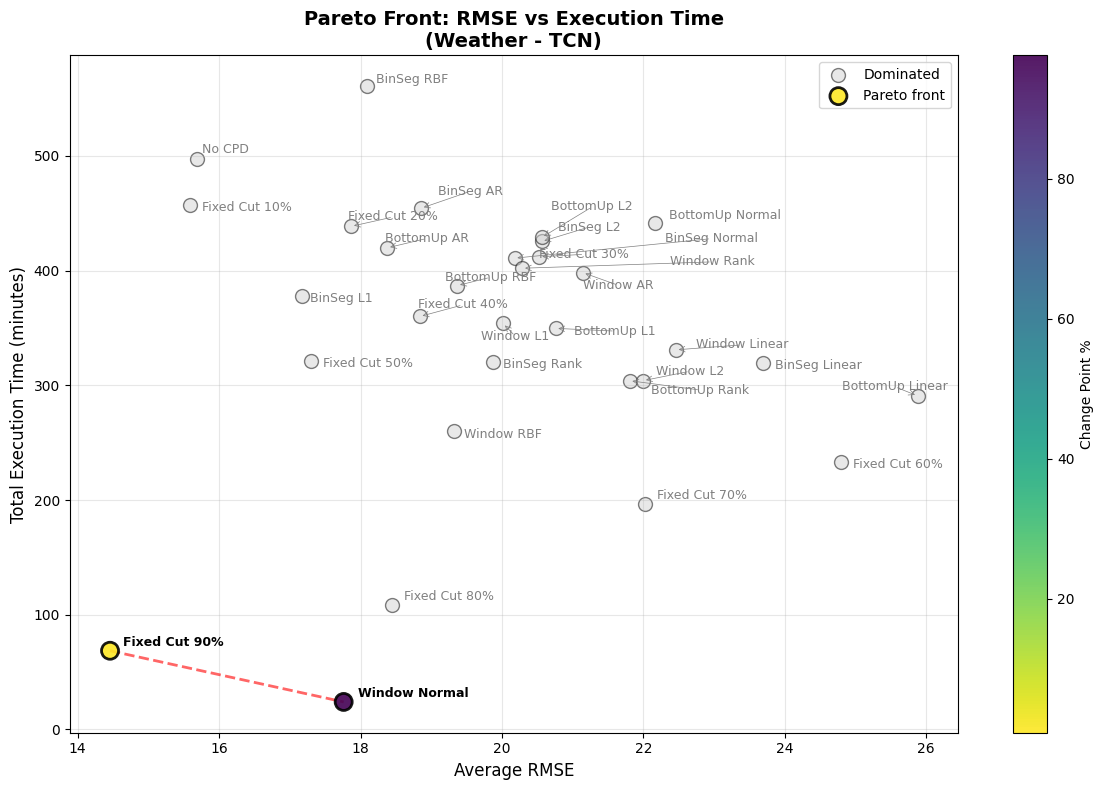


Pareto Optimal Approaches - Weather / TCN (optimizing RMSE and ET):
Fixed Cut 90%                  | RMSE: 14.4567 | ET:    68.63 min
Window Normal                  | RMSE: 17.7616 | ET:    24.02 min


In [16]:
# Pareto fronts per forecaster
for forecaster in FORECASTER_TYPES:
    print(f"\n{forecaster}:")
    for ds in DATASETS_NAMES:
        df = all_comp_dfs[forecaster][all_comp_dfs[forecaster][DATASET_NAME_COL] == ds].copy().rename(columns={
            f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL,
            f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
            f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
        })
        plot_pareto_front(df, f"{OUTPUT_FOLDER}/{forecaster}", PRIMARY_METRIC, 
                          filename=f"{ds}_pareto.png", dataset_name=ds, forecaster_type=forecaster)

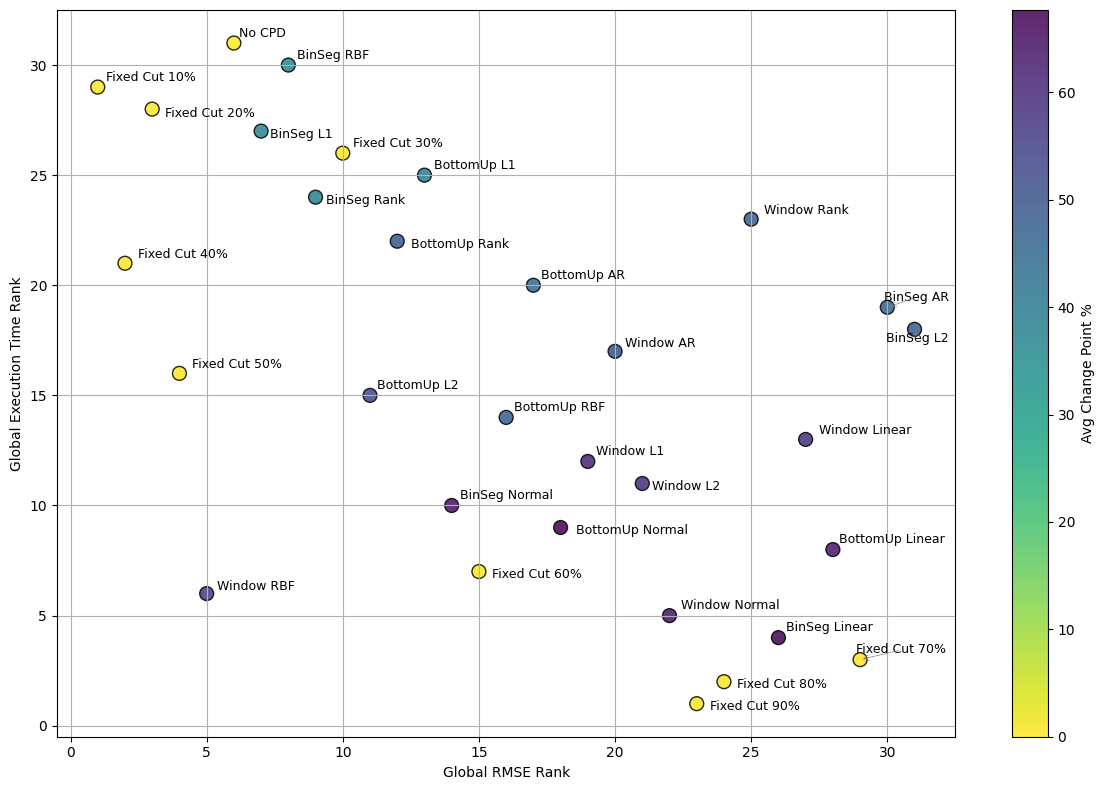

,change_point_approach,Avg_RMSE_mean,ET_Total_mean,change_point_perc_seed_0,metric_rank,et_rank
0,BinSeg AR,22.636242,118.332067,46.743783,30.0,19.0
1,BinSeg L1,17.158800,146.506875,37.334833,7.0,27.0
2,BinSeg L2,22.980817,117.519650,48.788133,31.0,18.0
3,BinSeg Linear,19.526750,76.243958,67.348783,26.0,4.0
4,BinSeg Normal,17.851708,92.436892,64.465983,14.0,10.0
5,BinSeg RBF,17.222500,186.497658,36.592967,8.0,30.0
6,BinSeg Rank,17.381283,139.970133,38.605833,9.0,24.0
7,BottomUp AR,17.916875,123.098567,45.220167,17.0,20.0
8,BottomUp L1,17.829642,142.640067,39.286150,13.0,25.0
9,BottomUp L2,17.713475,105.253192,53.124667,11.0,15.0


In [17]:
# Combined aggregated scatter
plot_aggregated_scatter(combined_df, OUTPUT_FOLDER, PRIMARY_METRIC, "aggregated_scatter_combined.png")